# Statistical Arbitrage Strategy - A Magnificent 7 Mean Reversion Model

This project builds a porfolio using the Magnificent 7 stocks and test whether an arbitrage strategy with a Information Technology sector benchmark can be succesfull.

## Methodology

1. Identify a portfolio of Mag7 stocks that cointegrates with the Information Technology sector benchmark (VGT)
2. Calculate the spread between the benchmark and the synthetic benchmark and test for stationarity
3. Convert to Z-Scores and define a trading strategy
4. Test against unseen data

## Data
We pull five years of daily close data for the Information Technology sector benchmark **(VGT)** as well as the Magnificent 7 stock prices. The window is fixed (2020-12-01 to 2026-03-31) so results are fully reproducible; any student can re-run and get the same time series. 

In [1]:
import yfinance as yf, pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, math

from datetime import datetime, timedelta
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

from scipy.stats import norm
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler

from statsmodels import regression, stats
from statsmodels.tsa.stattools import coint, adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

# Plot dictionaries
crimson = '#A51C30'
title_font_dict = {'fontsize': 12, 
                   'color': crimson, 
                   'fontweight': 'bold'}
axis_font_dict = {'color': crimson, 
                  'fontweight': 'bold'}

In [2]:
indices = ['VGT']
mag7 = ['GOOG', 'AAPL', 'AMZN', 'META', 'MSFT', 'NVDA', 'TSLA']
start_date = '2020-01-01'
end_date = '2026-03-31'

stocks_df = yf.download(tickers = indices + mag7, start = start_date, end = end_date)['Close']
stocks_df.head()

[*********************100%***********************]  8 of 8 completed


Ticker,AAPL,AMZN,GOOG,META,MSFT,NVDA,TSLA,VGT
Date,,,,,,,,
2020-01-02,72.400536,94.900497,67.811760,208.146561,152.158386,5.970755,28.684000,238.168137
2020-01-03,71.696625,93.748497,67.479004,207.045212,150.263763,5.875186,29.534000,235.665512
2020-01-06,72.267944,95.143997,69.142845,210.944611,150.652145,5.899825,30.102667,236.448776
2020-01-07,71.928040,95.343002,69.099693,211.401016,149.278534,5.971253,31.270666,236.420074
2020-01-08,73.085114,94.598503,69.644226,213.544205,151.656311,5.982452,32.809334,238.913147


In [3]:
stocks_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1568 entries, 2020-01-02 to 2026-03-30
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    1568 non-null   float64
 1   AMZN    1568 non-null   float64
 2   GOOG    1568 non-null   float64
 3   META    1568 non-null   float64
 4   MSFT    1568 non-null   float64
 5   NVDA    1568 non-null   float64
 6   TSLA    1568 non-null   float64
 7   VGT     1567 non-null   float64
dtypes: float64(8)
memory usage: 110.2 KB


In [4]:
# Compute returns
returns_df = stocks_df.pct_change().dropna()
returns_df

/var/folders/z8/qc61wsyd6_9929djpf07ffgh0000gn/T/ipykernel_63475/3780091871.py:2: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_df = stocks_df.pct_change().dropna()


Ticker,AAPL,AMZN,GOOG,META,MSFT,NVDA,TSLA,VGT
Date,,,,,,,,
2020-01-03,-0.009722,-0.012139,-0.004907,-0.005291,-0.012452,-0.016006,0.029633,-0.010508
2020-01-06,0.007969,0.014886,0.024657,0.018834,0.002585,0.004194,0.019255,0.003324
2020-01-07,-0.004703,0.002092,-0.000624,0.002164,-0.009118,0.012107,0.038801,-0.000121
2020-01-08,0.016087,-0.007809,0.007880,0.010138,0.015928,0.001875,0.049205,0.010545
2020-01-09,0.021241,0.004799,0.011045,0.014311,0.012493,0.010983,-0.021945,0.011235
...,...,...,...,...,...,...,...,...
2026-03-24,0.000596,-0.013800,-0.032841,-0.018442,-0.026789,-0.002505,0.005724,-0.005276
2026-03-25,0.003894,0.021569,0.001348,0.003323,-0.004561,0.019863,0.007623,0.006405
2026-03-26,0.001069,-0.019697,-0.030560,-0.079595,-0.013664,-0.041639,-0.035860,-0.028501


# Magnificent 7 Overview

The Magnificent 7, or MAG 7, is a group of technology companies with a total market cap of **\$21.66T** and **\$2.37T** in revenue.

The group, which consists of Alphabet, Amazon, Apple, Meta Platforms, Microsoft, Nvidia, and Tesla, has experienced substancial growth in the past decade and enjoys outsized influence in the setting the direction of the tech industry.

The returns of these 7 stocks are highly correlated with each other and with the Information Technology sector benchmark making them a good candidate for exploring an arbitrage strategy.

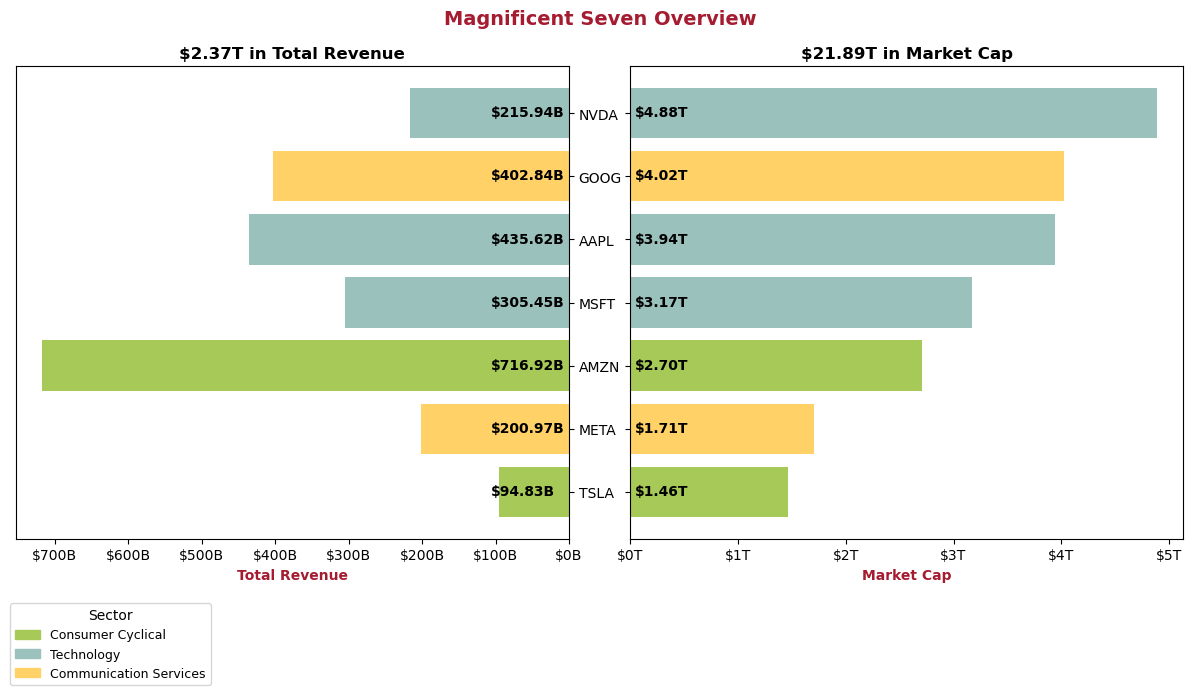

In [5]:
# Magnificent Seven
mag7 = ['GOOG', 'AAPL', 'AMZN', 'META', 'MSFT', 'NVDA', 'TSLA']
sector_colors = {'Consumer Cyclical': '#a7c957',
                 'Technology': '#9bc1bc',
                 'Communication Services': '#ffd166'}

# Get Info
mag7_info_df = pd.DataFrame()
for s in mag7:
    ticker = yf.Ticker(s)
    df = pd.DataFrame({'Symbol': [ticker.get_info()['symbol']],
                       'Name': [ticker.get_info()['shortName']],
                       'DisplayName': [ticker.get_info()['displayName']],
                       'Industry': [ticker.get_info()['industry']],
                       'Sector': [ticker.get_info()['sector']],
                       'MarketCap': [ticker.get_info()['marketCap']],
                       'TotalRevenue': [ticker.get_info()['totalRevenue']]})
    mag7_info_df = pd.concat([mag7_info_df, df])\
        .sort_values(by = 'MarketCap', ascending = True)\
        .reset_index(drop = True)

# Plot Revenue and Market Cap
fig, axes = plt.subplots(figsize = (12, 6), ncols = 2, sharey = True)

# Revenue Chart
axes[0].barh(mag7_info_df['TotalRevenue'].index.tolist(), 
             mag7_info_df['TotalRevenue'].values.tolist(), 
             align = 'center', 
             color = mag7_info_df['Sector'].map(sector_colors))
axes[0].set_title(f"${mag7_info_df['TotalRevenue'].sum() / 1e12:,.2f}T" + ' in Total Revenue',
                  fontweight = 'bold')
axes[0].invert_xaxis()
axes[0].set(yticks = mag7_info_df['Symbol'].index.tolist(), 
            yticklabels = mag7_info_df['Symbol'].values.tolist())
axes[0].yaxis.tick_right()
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e9:,.0f}B'))
axes[0].set_xlabel('Total Revenue', axis_font_dict)
for i in range(len(mag7_info_df)):
    axes[0].annotate(f"${mag7_info_df.iloc[i]['TotalRevenue'] / 1e9:,.2f}B",
                     xy = (mag7_info_df.iloc[i]['TotalRevenue'], i),
                     xytext = (1.07e11, i - 0.05),
                     fontsize = 10,
                     weight = 'bold')
    
# Market Cap Chart
axes[1].barh(mag7_info_df['TotalRevenue'].index.tolist(), 
             mag7_info_df['MarketCap'].values.tolist(), 
             align = 'center', 
             color = mag7_info_df['Sector'].map(sector_colors))
axes[1].set_title(f"${mag7_info_df['MarketCap'].sum() / 1e12:,.2f}T" + ' in Market Cap', 
                  fontweight = 'bold')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e12:,.0f}T'))
axes[1].set_xlabel('Market Cap', axis_font_dict)
for i in range(len(mag7_info_df)):
    axes[1].annotate(f"${mag7_info_df.iloc[i]['MarketCap'] / 1e12:,.2f}T",
                     xy = (mag7_info_df.iloc[i]['MarketCap'], i),
                     xytext = (5e10, i - 0.05),
                     fontsize = 10,
                     weight = 'bold')

# Plot Layout
fig.suptitle('Magnificent Seven Overview', fontsize = 14, fontweight = 'bold', color = '#A51C30')
fig.tight_layout()
fig.subplots_adjust(wspace = 0.11)
legend_patches = [mpatches.Patch(color = color, label = sector) for sector, color in sector_colors.items()]
fig.legend(handles = legend_patches, 
           title = 'Sector', 
           fontsize = 9, 
           title_fontsize = 10,
           bbox_to_anchor = (0.18, 0))
plt.show()

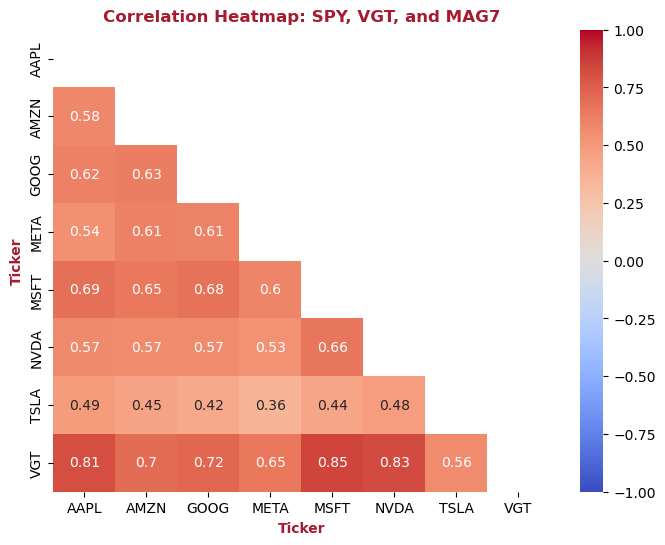

In [6]:
# Plot Correlation matrix
corr_matrix = returns_df.corr()

plt.figure(figsize = (8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype = bool))
sns.heatmap(corr_matrix, mask = mask, annot = True, cmap = 'coolwarm', vmin = -1, vmax = 1)
plt.title('Correlation Heatmap: SPY, VGT, and MAG7', title_font_dict)
plt.ylabel('Ticker', axis_font_dict)
plt.xlabel('Ticker', axis_font_dict)
plt.show()

# Train / Test Split

We will use the first three years of daily data as our train dataset and the remaining data up to the first quarter of 2026 as our test dataset.

In [7]:
test_date = '2022-12-31'

stocks_train_df = stocks_df[stocks_df.index <= '2022-12-31'].copy()
stocks_test_df = stocks_df[stocks_df.index > '2022-12-31'].copy()

print('Train data from ' + stocks_train_df.index.min().strftime('%B %d %Y') + ' thru ' + stocks_train_df.index.max().strftime('%B %d %Y'))
print('Test data from ' + stocks_test_df.index.min().strftime('%B %d %Y') + ' thru ' + stocks_test_df.index.max().strftime('%B %d %Y'))

Train data from January 02 2020 thru December 30 2022
Test data from January 03 2023 thru March 30 2026


# Identify Mag7 portfolio that cointegrates with VGT

We create the following three portfolios using the MAG7 stocks:

1. Equally weighted portfolio
2. Market Cap weighted portfolio
3. OLS weighted portfolio

After testing these 3 portfolios for cointegration with the Information Technology sector benchmark we then decided to proceed with the **OLS Weighted Portfolio** as it is the most suitable for the strategy given its cointegration with VGT.

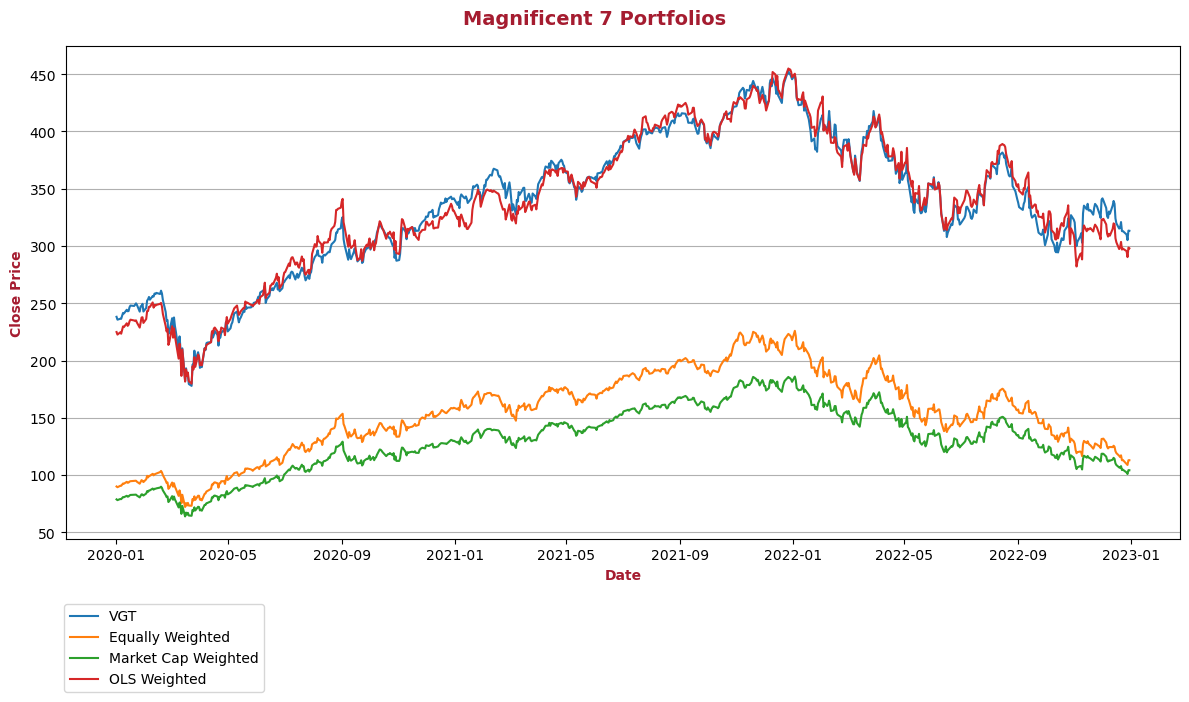

In [8]:
# Equally weighted portfolio
stocks_train_df['MAG7_EQ'] = stocks_train_df[mag7].mean(axis = 1)
stocks_test_df['MAG7_EQ'] = stocks_test_df[mag7].mean(axis = 1)

# Market Cap weighted portfolio
mag7_info_df['MarketCapPct'] = mag7_info_df['MarketCap'] / mag7_info_df['MarketCap'].sum()
mag7_info_df['Metric'] = 'Market Cap Weights'
mag7_cap_weights_df = mag7_info_df.pivot(index = 'Metric', columns = 'Symbol', values = 'MarketCapPct')

stocks_train_df['MAG7_MC'] = stocks_train_df['AAPL'] * mag7_cap_weights_df['AAPL'].iloc[0] + \
    stocks_train_df['AMZN'] * mag7_cap_weights_df['AMZN'].iloc[0] + \
    stocks_train_df['GOOG'] * mag7_cap_weights_df['GOOG'].iloc[0] + \
    stocks_train_df['META'] * mag7_cap_weights_df['META'].iloc[0] + \
    stocks_train_df['MSFT'] * mag7_cap_weights_df['MSFT'].iloc[0] + \
    stocks_train_df['NVDA'] * mag7_cap_weights_df['NVDA'].iloc[0] + \
    stocks_train_df['TSLA'] * mag7_cap_weights_df['TSLA'].iloc[0]
stocks_test_df['MAG7_MC'] = stocks_test_df['AAPL'] * mag7_cap_weights_df['AAPL'].iloc[0] + \
    stocks_test_df['AMZN'] * mag7_cap_weights_df['AMZN'].iloc[0] + \
    stocks_test_df['GOOG'] * mag7_cap_weights_df['GOOG'].iloc[0] + \
    stocks_test_df['META'] * mag7_cap_weights_df['META'].iloc[0] + \
    stocks_test_df['MSFT'] * mag7_cap_weights_df['MSFT'].iloc[0] + \
    stocks_test_df['NVDA'] * mag7_cap_weights_df['NVDA'].iloc[0] + \
    stocks_test_df['TSLA'] * mag7_cap_weights_df['TSLA'].iloc[0]

# OLS weighted portfolio
mag7_ols_model = LinearRegression(fit_intercept = False)
mag7_ols_model.fit(stocks_train_df[mag7], stocks_train_df['VGT'].to_numpy())
stocks_train_df['MAG7_OLS'] = mag7_ols_model.predict(stocks_train_df[mag7])
stocks_test_df['MAG7_OLS'] = mag7_ols_model.predict(stocks_test_df[mag7])

# Plot Porfolios against VGT
fig, ax = plt.subplots(figsize = (12, 6))

for s, l in zip(['VGT', 'MAG7_EQ', 'MAG7_MC', 'MAG7_OLS'], 
                ['VGT', 'Equally Weighted', 'Market Cap Weighted', 'OLS Weighted']):
    ax.plot(stocks_train_df.index, stocks_train_df[s], label = l)
    
fig.suptitle('Magnificent 7 Portfolios', fontsize = 14, fontweight = 'bold', color = '#A51C30')
ax.set_ylabel('Close Price', axis_font_dict)
ax.set_xlabel('Date', axis_font_dict)
fig.tight_layout()
fig.legend(bbox_to_anchor = (0.23, 0))
plt.grid(axis = 'y')
plt.show()

In [9]:
def coint_fun(df, stock1, stock2):
    score, pvalue, _ = coint(df[stock1], df[stock2])
    if pvalue < 0.05:
        print("Cointegration between " + stock1 + ' and ' + stock2 + ' (pvalue = ' + str(round(pvalue, 4)) + ')')
    else:
        print("No Cointegration between " + stock1 + ' and ' + stock2 + ' (pvalue = ' + str(round(pvalue, 4)) + ')')

for s in ['MAG7_EQ', 'MAG7_MC', 'MAG7_OLS']:
    coint_fun(stocks_train_df, 'VGT', s)

No Cointegration between VGT and MAG7_EQ (pvalue = 0.7433)
No Cointegration between VGT and MAG7_MC (pvalue = 0.3847)
Cointegration between VGT and MAG7_OLS (pvalue = 0.0352)


# Calculate Spread and Test for Stationarity

Now that the **OLS Weighted Portfolio** has been selected, we calculate the spread between the portfolio and VGT and test for stationarity of the timeseries.

The augmented Dickey–Fuller test (ADF) confirms that the **spread is stationary** and we proceed to develop a trading strategy.

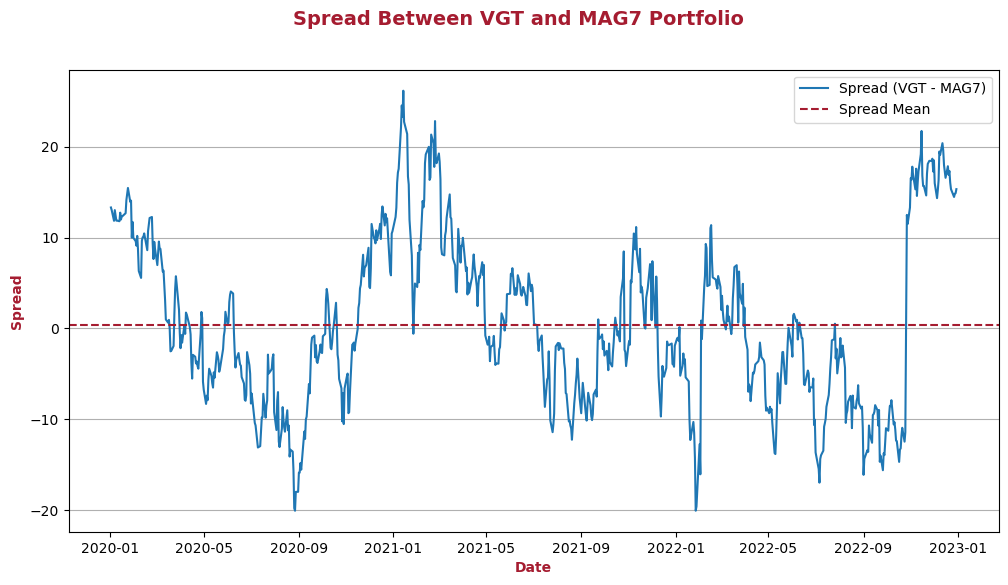

In [10]:
stocks_train_df['Spread'] = stocks_train_df['VGT'] - stocks_train_df['MAG7_OLS']
stocks_test_df['Spread'] = stocks_test_df['VGT'] - stocks_test_df['MAG7_OLS']

fig, ax = plt.subplots(figsize = (12, 6))
plt.plot(stocks_train_df.index, stocks_train_df["Spread"], label = 'Spread (VGT - MAG7)')
plt.axhline(stocks_train_df["Spread"].mean(), color = crimson, linestyle = '--', label = 'Spread Mean')
fig.suptitle('Spread Between VGT and MAG7 Portfolio', fontsize = 14, fontweight = 'bold', color = '#A51C30')
plt.legend()
ax.set_ylabel('Spread', axis_font_dict)
ax.set_xlabel('Date', axis_font_dict)
plt.grid(axis = 'y')
plt.show()

Ticker       Spread  Spread_Lag
Ticker                         
Spread      1.00000     0.96709
Spread_Lag  0.96709     1.00000


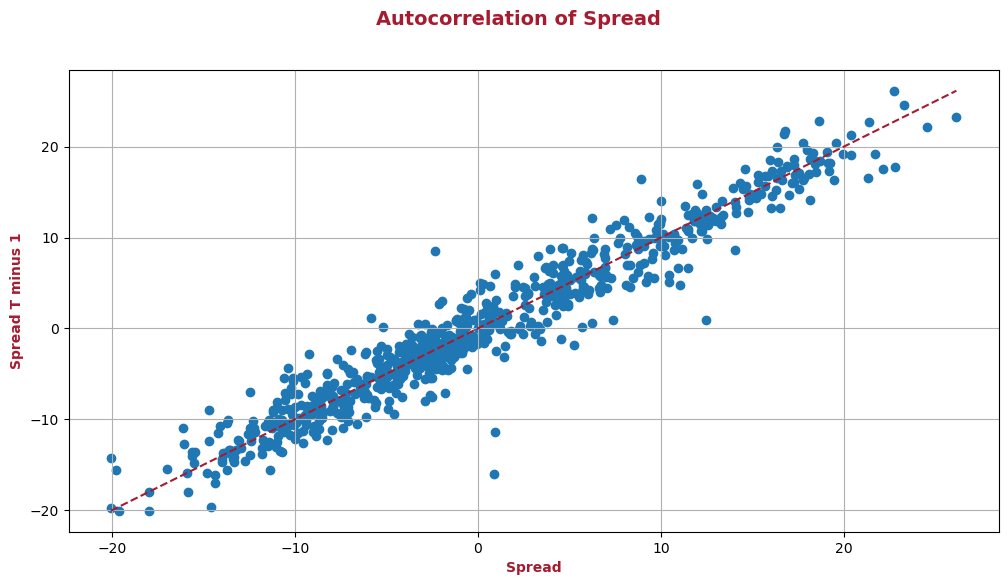

In [11]:
stocks_train_df['Spread_Lag'] = stocks_train_df['Spread'].shift(1)
spread_space = np.linspace(stocks_train_df['Spread'].min(), stocks_train_df['Spread'].max(), 100)

print(stocks_train_df[['Spread', 'Spread_Lag']].dropna().corr())
fig, ax = plt.subplots(figsize = (12, 6))
plt.scatter(x = 'Spread',
            y = 'Spread_Lag',
            data = stocks_train_df)
plt.plot(spread_space, spread_space, color = crimson, linestyle = '--')
fig.suptitle('Autocorrelation of Spread', fontsize = 14, fontweight = 'bold', color = '#A51C30')
ax.set_ylabel('Spread T minus 1', axis_font_dict)
ax.set_xlabel('Spread', axis_font_dict)
plt.grid()
plt.show()

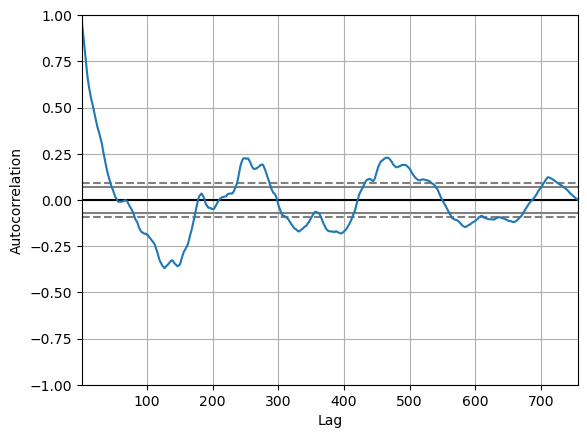

In [12]:
pd.plotting.autocorrelation_plot(stocks_train_df['Spread']);

In [13]:
ad_fuller_results = adfuller(stocks_train_df['Spread'])
adf_h0 = 'The series has a unit root (non-stationary)'
adf_ha = 'The series is stationary.'

if ad_fuller_results[1] < 0.05:
    print(adf_ha)
else:
    print(adf_h0)
print('ADF Statistic: ' + str(ad_fuller_results[0]))
print('p-value: ' + str(ad_fuller_results[1]))

The series is stationary.
ADF Statistic: -3.500702199016559
p-value: 0.00796907840630188


# Define Trading Strategy

At this point we've indentified cointegrated pairs and confirmed that the spread is stationary. Our next step is to try to identify when the assets are mispriced and short the overperforming stock.

We first convert the spread to a Z-score 30-day using a rolling window to smooth out the daily volatility of the stock prices.

We then create a function to capture the daily returns when the position of VGT and MAG7 was either Long or Short and calculate the hypothetical growth of trading the positions.

In [14]:
df_cols = stocks_test_df.columns

In [15]:
# Compute Z-score
rolling_window = 30

zscore_df = pd.concat([stocks_train_df[['VGT', 'MAG7_OLS', 'Spread']],
                       stocks_test_df[['VGT', 'MAG7_OLS', 'Spread']]])
zscore_df["Spread_Mean"] = zscore_df["Spread"].rolling(rolling_window).mean()
zscore_df["Spread_SD"] = zscore_df["Spread"].rolling(rolling_window).std()
zscore_df["Zscore"] = (zscore_df["Spread"] - zscore_df["Spread_Mean"]) / zscore_df["Spread_SD"]

# Append Zscore to Train/Test sets
stocks_train_df = stocks_train_df[df_cols].merge(zscore_df[['Zscore']], left_index = True, right_index = True)
stocks_test_df = stocks_test_df[df_cols].merge(zscore_df[['Zscore']], left_index = True, right_index = True)

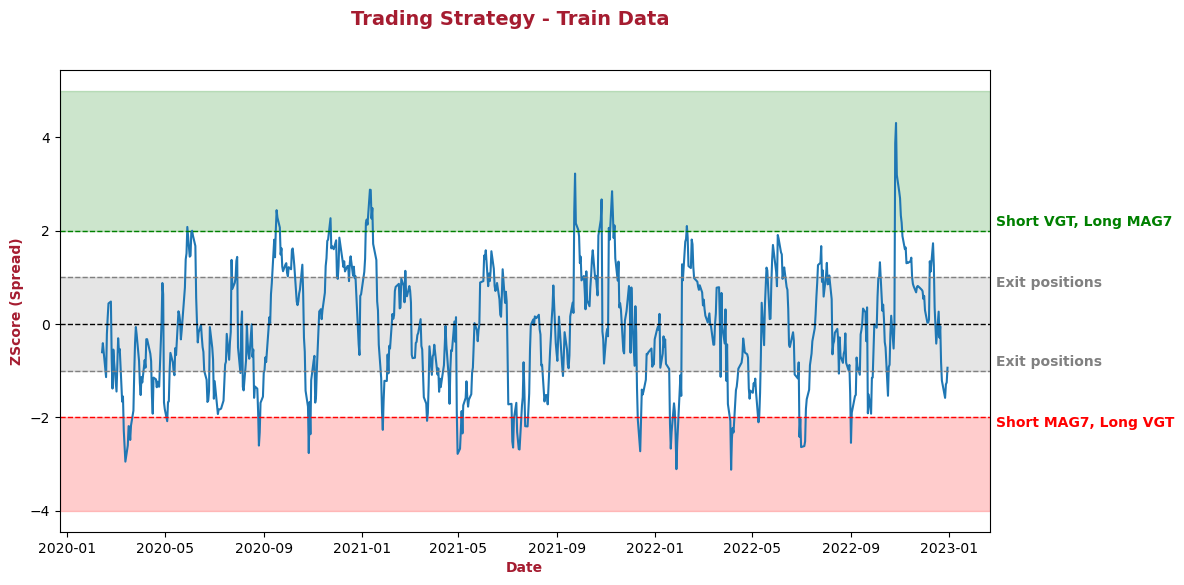

In [16]:
# Plot
fig, ax = plt.subplots(figsize = (12, 6))
plt.plot(stocks_train_df.index, stocks_train_df["Zscore"])
plt.axhline(0, color = "black", linestyle = "--", lw = 1)

# Positive spread: VGT outperforming so short VGT, Long MAG7
plt.axhline(2.0, color = "green", linestyle = "--", lw = 1)
plt.axhspan(ymin = 2, ymax = math.ceil(stocks_train_df["Zscore"].max()), color = 'green', alpha = 0.2)
ax.annotate("Short VGT, Long MAG7",
            xy = (stocks_train_df.index.max(), 2),
            xytext = (stocks_train_df.index.max() + timedelta(days = 60), 2.1),
            color = 'green',
            fontsize = 10,
            weight = 'bold')

# Negative spread: Mag7 outperforming so short MAG7, Long VGT
plt.axhline(-2.0, color = "red", linestyle = "--", lw = 1)
plt.axhspan(ymin = math.floor(stocks_train_df["Zscore"].min()), ymax = -2, color = 'red', alpha = 0.2)
ax.annotate("Short MAG7, Long VGT",
            xy = (stocks_train_df.index.max(), -2),
            xytext = (stocks_train_df.index.max() + timedelta(days = 60), -2.2),
            color = 'red',
            fontsize = 10,
            weight = 'bold')

# Exit positions
plt.axhline(1.0, color = "grey", linestyle = "--", lw = 1)
plt.axhline(-1.0, color = "grey", linestyle = "--", lw = 1)
plt.axhspan(ymin = -1, ymax = 1, color = 'grey', alpha = 0.2)
ax.annotate("Exit positions",
            xy = (stocks_train_df.index.max(), 1),
            xytext = (stocks_train_df.index.max() + timedelta(days = 60), 0.8),
            color = 'grey',
            fontsize = 10,
            weight = 'bold')
ax.annotate("Exit positions",
            xy = (stocks_train_df.index.max(), -1),
            xytext = (stocks_train_df.index.max() + timedelta(days = 60), -0.9),
            color = 'grey',
            fontsize = 10,
            weight = 'bold')

fig.suptitle('Trading Strategy - Train Data', fontsize = 14, fontweight = 'bold', color = '#A51C30')
ax.set_ylabel('ZScore (Spread)', axis_font_dict)
ax.set_xlabel('Date', axis_font_dict)
plt.show()

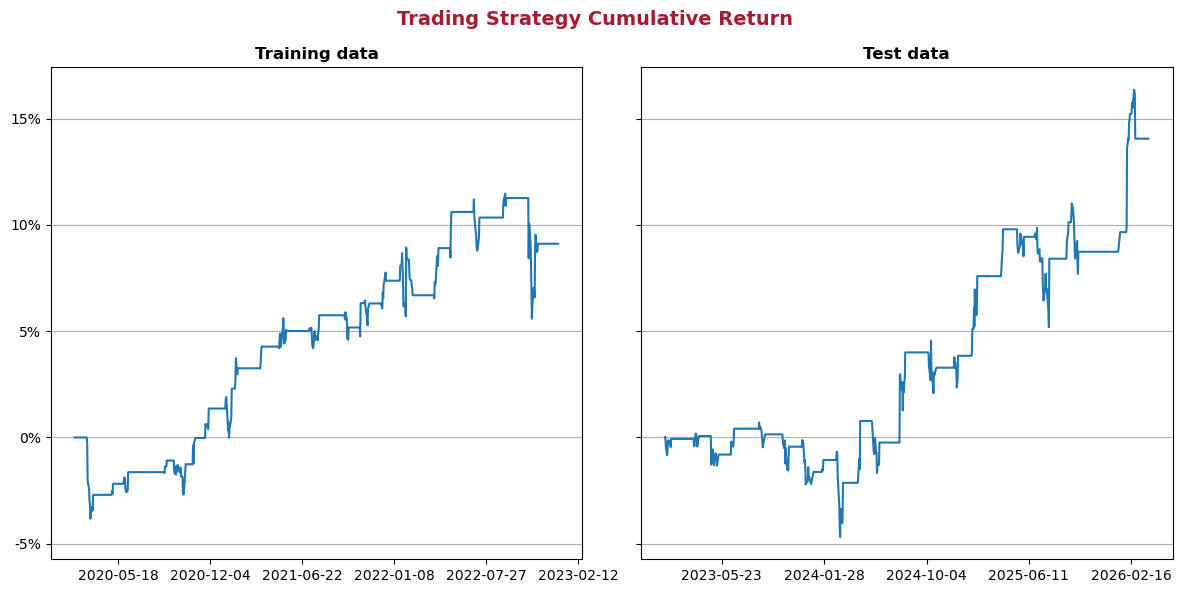

In [23]:
def trading_fun(df, vgt_initial_balance = 10000, mg7_initial_balance = 10000):
    
    # Add daily returns
    df['VGT_Return'] = df['VGT'].pct_change(fill_method = None).fillna(0.0)
    df['MAG7_Return'] = df['MAG7_OLS'].pct_change(fill_method = None).fillna(0.0)
    df = df[['VGT', 'MAG7_OLS', 'Zscore', 'VGT_Return', 'MAG7_Return']].dropna()
    trading_days = df.shape[0]
            
    # Trading signals: 
    # Short VGT and Long MAG7 (Zscore > 2), or Long VGT and Short MAG7 (Zscore < 2), or exit position (-1 < Zscore < 1)
    # If no trading signal, previous position carries over
    df.loc[df["Zscore"] > 2, ["VGT_Signal", "MAG7_Signal"]] = [-1, 1]
    df.loc[df["Zscore"] < -2, ["VGT_Signal", "MAG7_Signal"]] = [1, -1]
    df.loc[(df["Zscore"] > -1) & (df["Zscore"] < 1), ["VGT_Signal", "MAG7_Signal"]] = [0, 0]
    for c in ['VGT_Signal', 'MAG7_Signal']:
        df[c] = df[c].ffill().fillna(0)

    # Return realized if in a short or long position
    vgt_equity = [vgt_initial_balance]
    mag7_equity = [mg7_initial_balance]
    
    df['VGT_Return_Lag'] = [r * s for s, r in zip(df['VGT_Signal'].shift(1), df['VGT_Return'])]
    df['VGT_Return_Lag'] = df['VGT_Return_Lag'].fillna(0)
    df['MAG7_Return_Lag'] = [r * s for s, r in zip(df['MAG7_Signal'].shift(1), df['MAG7_Return'])]
    df['MAG7_Return_Lag'] = df['MAG7_Return_Lag'].fillna(0)

    for d in range(1, trading_days):
        vgt_equity = vgt_equity + [vgt_equity[d-1] * (1 + df['VGT_Return_Lag'].iloc[d])]
        mag7_equity = mag7_equity + [mag7_equity[d-1] * (1 + df['MAG7_Return_Lag'].iloc[d])]
    df['VGT_Equity'] = vgt_equity
    df['MAG7_Equity'] = mag7_equity
    df['Equity'] = df['VGT_Equity'] + df['MAG7_Equity']
    df = df.drop(['VGT_Return_Lag', 'MAG7_Return_Lag'], axis = 1)
    df['Equity_Return'] = df['Equity'].pct_change(fill_method = None).cumsum()
    
    return df

positions_train_df = trading_fun(stocks_train_df, vgt_initial_balance = 100000, mg7_initial_balance = 100000)
positions_test_df = trading_fun(stocks_test_df, vgt_initial_balance = 100000, mg7_initial_balance = 100000)

# Plot Equity Return
fig, axes = plt.subplots(figsize = (12, 6), ncols = 2, sharey = True)

# Training data
axes[0].plot(positions_train_df.index, positions_train_df['Equity_Return'])
axes[0].set_title('Training data', fontweight = 'bold')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0%}'))
axes[0].grid(axis = 'y')
axes[0].xaxis.set_major_locator(mticker.MaxNLocator(nbins = 6))
    
# Test data
axes[1].plot(positions_test_df.index, positions_test_df['Equity_Return'])
axes[1].set_title('Test data', fontweight = 'bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0%}'))
axes[1].grid(axis = 'y')
axes[1].xaxis.set_major_locator(mticker.MaxNLocator(nbins = 6))

# Plot Layout
fig.suptitle('Trading Strategy Cumulative Return', fontsize = 14, fontweight = 'bold', color = '#A51C30')
fig.tight_layout()
fig.subplots_adjust(wspace = 0.11)
plt.show()

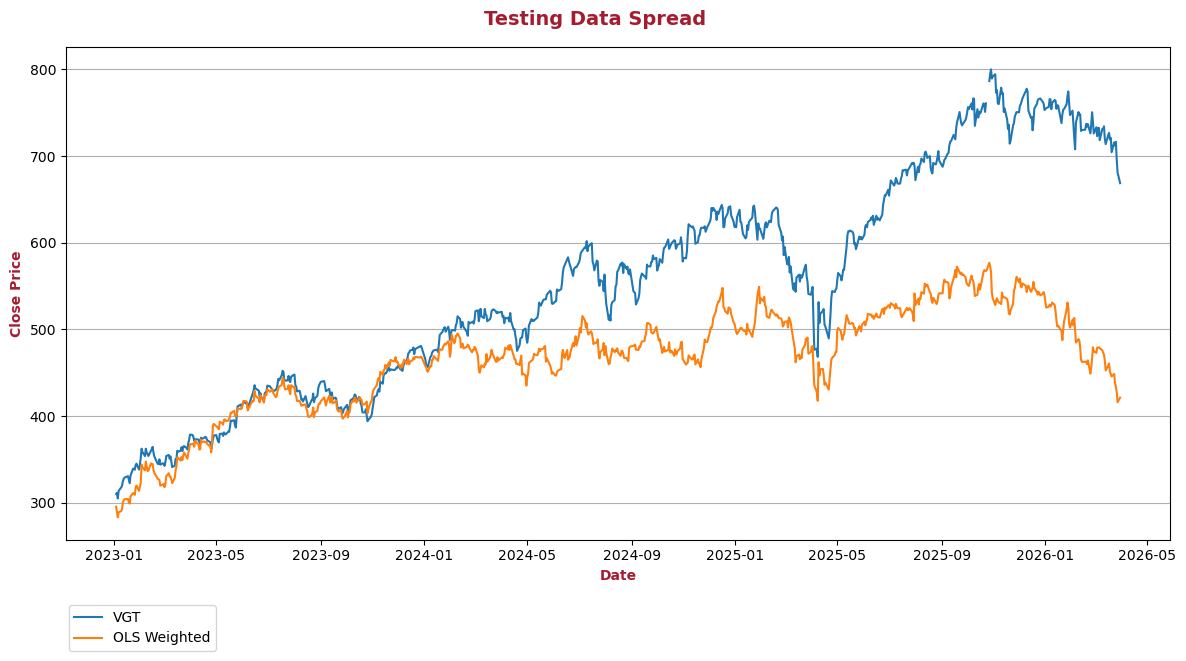

In [31]:
fig, ax = plt.subplots(figsize = (12, 6))

for s, l in zip(['VGT', 'MAG7_OLS'], 
                ['VGT', 'OLS Weighted']):
    ax.plot(stocks_test_df.index, stocks_test_df[s], label = l)
    
fig.suptitle('Testing Data Spread', fontsize = 14, fontweight = 'bold', color = '#A51C30')
ax.set_ylabel('Close Price', axis_font_dict)
ax.set_xlabel('Date', axis_font_dict)
fig.tight_layout()
fig.legend(bbox_to_anchor = (0.19, 0))
plt.grid(axis = 'y')
plt.show()

# Conclusion